Setting directories and device

In [1]:
from google.colab import drive
import torch
import os

drive.mount('/content/drive')
notebook_path = '/content/drive/My Drive/Colab Notebooks/SC4001 AY2526 Project'
os.chdir(notebook_path)
torch.hub.set_dir(notebook_path)
print("Current working directory:", os.getcwd())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Current working directory: /content/drive/My Drive/Colab Notebooks/SC4001 AY2526 Project
Using device: cpu


Importing modules and setting seeds

In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, default_collate

import torchvision
from torchvision.transforms import v2
from torchvision import datasets, transforms, models

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

Choose the pretrained torchvision models that will be used on the dataset and create a function to appropriately configure them for the dataset

In [3]:
# Define model configurations as a list of dicts
model_configs = [
    {
        "name": "VGG-11_BN",
        "model_fn": models.vgg11_bn,
        "weights": models.VGG11_BN_Weights.IMAGENET1K_V1,
        "classifier_attr": "classifier",
        "classifier_layer_index": -1   # VGG: last layer of classifier
    },
    {
        "name": "ResNet18",
        "model_fn": models.resnet18,
        "weights": models.ResNet18_Weights.IMAGENET1K_V1,
        "classifier_attr": "fc",
        "classifier_layer_index": None  # ResNet: just replace model.fc
    },
    {
        "name": "Swin_T",
        "model_fn": models.swin_t,
        "weights": models.Swin_T_Weights.IMAGENET1K_V1,
        "classifier_attr": "head",
        "classifier_layer_index": None # Swin_T: just replace model.head
    }
]

BATCH_SIZE = 128
NUM_FLOWER_CLASSES = 102

def process_cfg(cfg):
    """Processes a model config to return the model with corrected output shape"""
    # Load pre-trained model
    model = cfg["model_fn"](weights=cfg["weights"])

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classifier head
    if cfg["classifier_layer_index"] is not None:
        # For VGG: classifier is a Sequential, replace the last layer
        classifier = getattr(model, cfg["classifier_attr"])
        in_features = classifier[cfg["classifier_layer_index"]].in_features
        classifier[cfg["classifier_layer_index"]] = nn.Linear(in_features, NUM_FLOWER_CLASSES)
    else:
        # For ResNet and Swin: directly replace fc or head
        classifier = getattr(model, cfg["classifier_attr"])
        in_features = classifier.in_features
        setattr(model, cfg["classifier_attr"], nn.Linear(in_features, NUM_FLOWER_CLASSES))

    return model

Create helper functions/classes for a model's training, validation and testing phases and a function `collate_fn` to apply the mixup transformation to batches of the training set for the mixup experiments (used by the dataloader to mixup the whole set)


In [4]:
class EarlyStopper:
    def __init__(self, patience=5, min_delta=0.1):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    #Stops training if validation loss fails to improve by at least {min_delta} for {patience} consecutive epochs.
    def early_stop(self, validation_loss):
        if validation_loss < (self.min_validation_loss - self.min_delta):
            self.min_validation_loss = validation_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

def compute_correct(outputs, labels):
    """Compute number of correct predictions."""
    _, predictions = torch.max(outputs, dim=1)
    return (predictions == labels).sum().item()

def compute_correct(outputs, labels):
    """Compute number of correct predictions."""
    # labels may be hard labels, shape (batch,), or soft labels from MixUp, shape
    # (batch, num_classes); argmax handles both uniformly. Slightly overstates
    # Mixup accuracy; loss unaffected since CELoss handles soft labels natively
    _, predictions = torch.max(outputs, dim=1)
    if labels.dim() > 1: labels = labels.argmax(dim=1)
    return (predictions == labels).sum().item()

def train(model, tl, vl, epochs=100):
    """Trains model on train set and evaluates on validation set for early stopping"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.cuda.empty_cache()
    model = model.to(device)

    print(f"Training {model.name} on device: {device}")

    early_stopper = EarlyStopper()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.0005)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    train_accuracies, train_losses, val_accuracies, val_losses, times = [], [], [], [], epochs

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        epoch_train_correct = 0
        for X_batch, y_batch in tl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            epoch_train_correct += compute_correct(outputs, y_batch)
        avg_train_loss = epoch_train_loss / len(tl)
        avg_train_acc = epoch_train_correct / len(tl.dataset)

        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in vl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                epoch_val_loss += loss.item()
                epoch_val_correct += compute_correct(outputs, y_batch)
        avg_val_loss = epoch_val_loss / len(vl)
        avg_val_acc = epoch_val_correct / len(vl.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(avg_train_acc)
        val_accuracies.append(avg_val_acc)
        scheduler.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
                f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

        # Early stopping check (using val loss)
        if early_stopper.early_stop(avg_val_loss):
            times = epoch + 1
            print(f"Early stopping triggered at epoch {times}")
            break

    print(f"\nFinal Train Accuracy: {train_accuracies[-1]:.4f}")
    print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

    return train_accuracies, train_losses, val_accuracies, val_losses, times

def test(model, ttl):
    """Evaluates model on test set"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.cuda.empty_cache()
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    print(f"Testing {model.name} on device: {device}")

    # Testing phase
    model.eval()
    test_loss = 0.0
    test_correct = 0
    with torch.no_grad():
        for X_batch, y_batch in ttl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            test_loss += loss.item()
            test_correct += compute_correct(outputs, y_batch)
    avg_test_loss = test_loss / len(ttl)
    avg_test_acc = test_correct / len(ttl.dataset)

    print(f"Test Loss: {avg_test_loss:.4f}, Test Acc: {avg_test_acc:.4f}")

    return avg_test_acc, avg_test_loss

def collate_fn(batch):
    """Returns the mixup transformed batch; used in dataloader args to mixup all batches"""
    mixup = v2.MixUp(num_classes=NUM_FLOWER_CLASSES)
    return mixup(*default_collate(batch))

Conduct the mixup experiments for each model architecture

In [5]:
mixup_results = []
for cfg in model_configs:
    print(f"\n--- Processing {cfg['name']} ---")

    # Get the official transform
    transform = cfg["weights"].transforms()

    # Create datasets (each model architecture gets its own, but they share the same downloaded images)
    train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
    val_dataset   = datasets.Flowers102(root='./data', split='val',   download=True, transform=transform)
    test_dataset  = datasets.Flowers102(root='./data', split='test',  download=True, transform=transform)

    # Create the val and test dataloaders
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Create the train dataloader using the mixup collate_fn
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_fn)

    # Load processed model
    model = process_cfg(cfg)
    model.name = cfg["name"] + "_mixup"
    save_path = './checkpoints/' + model.name + '.pth'

    if os.path.exists(save_path):
        print(f"\nLoading results from {save_path}")
        ckpt = torch.load(save_path, map_location=device)
        trv_results = ckpt["trv_results"]
        t_results =  ckpt["t_results"]
    else:
        print(f"\n{save_path} does not exist, training from scratch...")
        trv_results = train(model, train_loader, val_loader)
        t_results = test(model, test_loader)

        # Save model state dict
        torch.save({
            'model_state_dict': model.state_dict(),
            'trv_results': trv_results,
            't_results': t_results
        }, save_path)
        print(f"Model saved successfully to {save_path}")

    mixup_results.append({
        "name": model.name,
        "trv_results": trv_results,
        "t_results": t_results
    })

    # After training, delete to free memory
    del model, train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset


--- Processing VGG-11_BN ---

Loading results from ./checkpoints/VGG-11_BN_mixup.pth

--- Processing ResNet18 ---

Loading results from ./checkpoints/ResNet18_mixup.pth

--- Processing Swin_T ---

Loading results from ./checkpoints/Swin_T_mixup.pth


Parse the results from the mixup experiments and show some of the results as tables and plots (include the results from 10 shot learning as a reference)


Loading results from ./checkpoints/VGG-11_BN_10shot.pth

Loading results from ./checkpoints/ResNet18_10shot.pth

Loading results from ./checkpoints/Swin_T_10shot.pth
MIXUP RESULTS SUMMARY
    Model Transform  Epochs Ran  Final Train Acc (%)  Final Val Acc (%)  Final Train Loss  Final Val Loss  Test Acc (%)  Test Loss
VGG-11_BN     Mixup          15                92.75              78.43            1.4412          0.9388         77.49     0.9861
 ResNet18     Mixup          12                87.06              80.88            1.7355          1.1024         77.52     1.1829
   Swin_T     Mixup          11                73.63              86.37            1.8829          0.7201         83.61     0.7939
VGG-11_BN      Base           9                99.90              83.63            0.0162          0.6372         80.99     0.7253
 ResNet18      Base          11               100.00              84.80            0.0856          0.7344         83.04     0.7864
   Swin_T      Base      

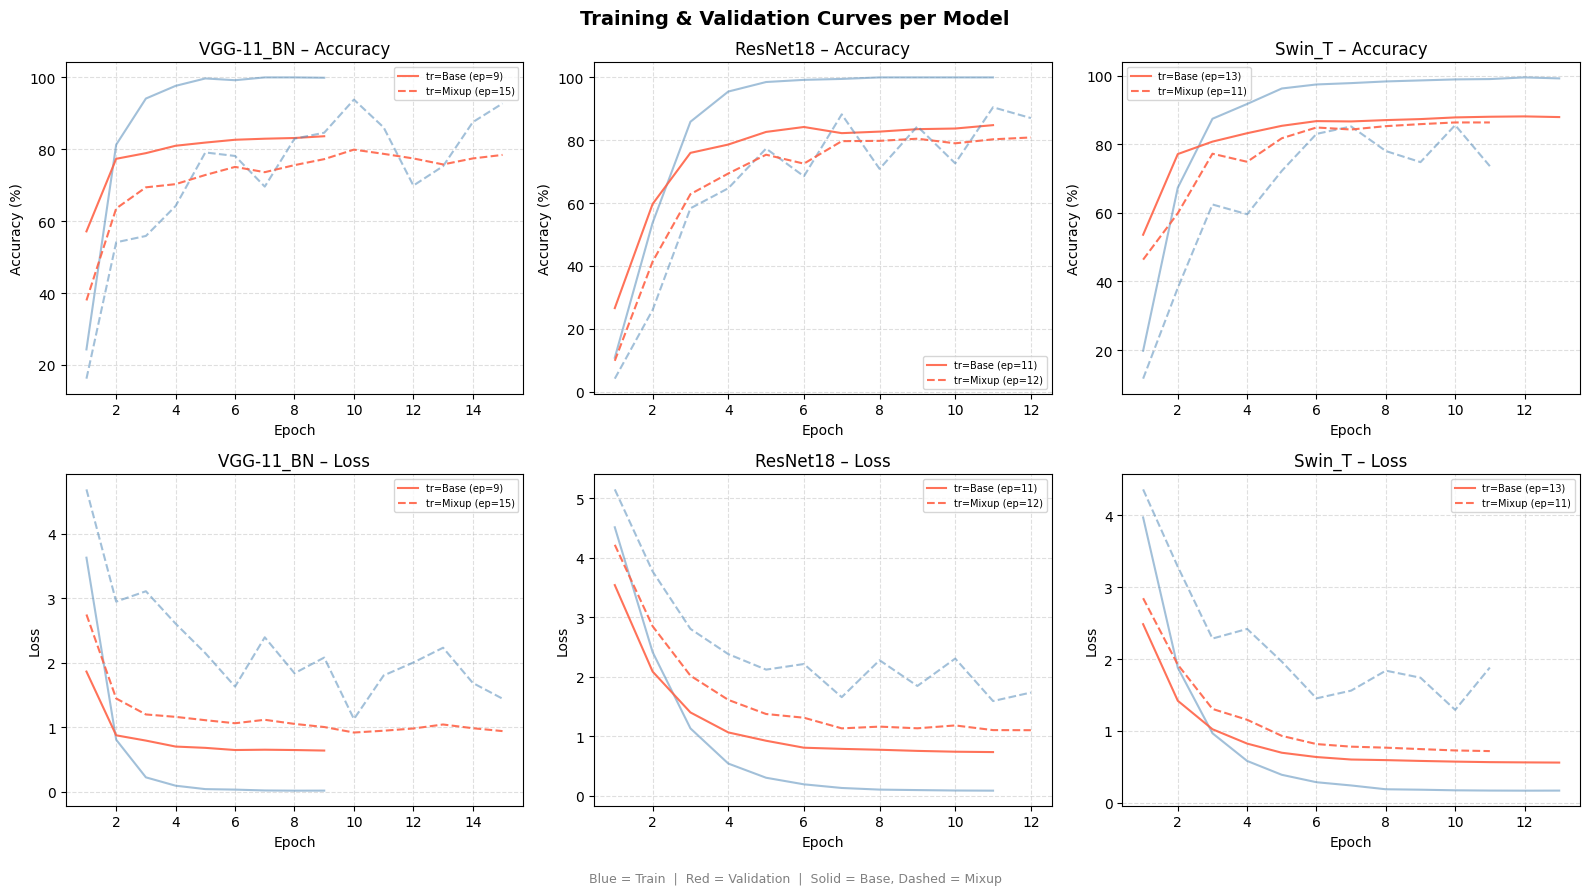

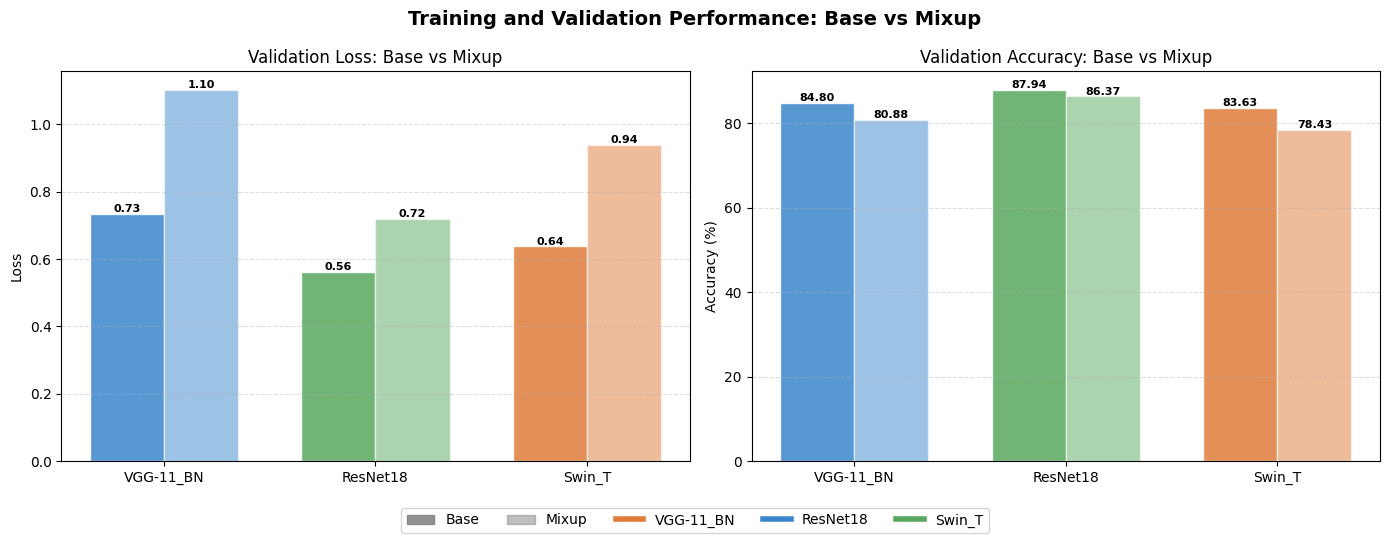

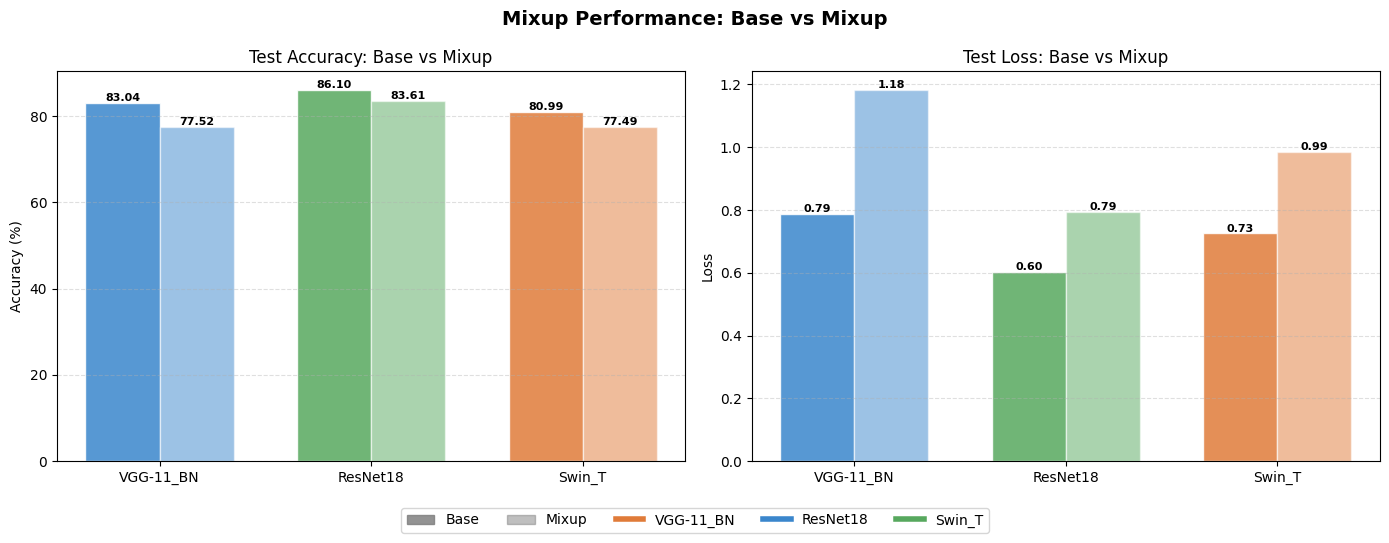

In [6]:
# Parse mixup_results
models_list  = ['VGG-11_BN', 'ResNet18', 'Swin_T']

# Add 10 shot learning results into mixup_results
for model in models_list:
    model_name = model + "_10shot"
    save_path = './checkpoints/' + model_name + '.pth'

    if os.path.exists(save_path):
        print(f"\nLoading results from {save_path}")
        ckpt = torch.load(save_path, map_location=device)
        mixup_results.append({
            "name": model_name,
            "trv_results": ckpt["trv_results"],
            "t_results": ckpt["t_results"]
        })
    else:
        print(f"\n{save_path} does not exist, skip inclusion...")

rows = []
for entry in mixup_results:
    name = entry['name']                       # e.g. 'ResNet18_mixup'
    train_accs, train_losses, val_accs, val_losses, epochs_ran = entry['trv_results']
    test_acc, test_loss = entry['t_results']

    # Parse model name and transform from the stored name string
    parts  = name.rsplit('_', 1)               # ['ResNet18', 'mixup']
    model  = parts[0]
    transform  = "Mixup" if parts[1] == 'mixup' else 'Base'

    rows.append({
        'Model':               model,
        'Transform':           transform,
        'Epochs Ran':          epochs_ran,
        'Final Train Acc (%)': round(train_accs[-1]  * 100, 2),
        'Final Train Loss':    round(train_losses[-1],      4),
        'Final Val Acc (%)':   round(val_accs[-1]    * 100, 2),
        'Final Val Loss':      round(val_losses[-1],        4),
        'Test Acc (%)':        round(test_acc        * 100, 2),
        'Test Loss':           round(test_loss,             4),
        # keep raw lists for plotting
        '_train_accs':         train_accs,
        '_val_accs':           val_accs,
        '_train_losses':       train_losses,
        '_val_losses':         val_losses
    })

df_full = pd.DataFrame(rows)

# Summary tables
display_cols = ['Model', 'Transform', 'Epochs Ran',
                'Final Train Acc (%)', 'Final Val Acc (%)', 'Final Train Loss', 'Final Val Loss',
                'Test Acc (%)', 'Test Loss']

print("="*105)
print("MIXUP RESULTS SUMMARY")
print("="*105)
print(df_full[display_cols].to_string(index=False))

# Best val accuracy per model (Base vs Mixup per architecture)
print("\n" + "─"*105)
print("BEST VAL ACCURACY PER MODEL ARCHITECTURE")
print("─"*105)
best = df_full.loc[df_full.groupby('Model')['Final Val Acc (%)'].idxmax(),
                   ['Model', 'Transform', 'Final Val Acc (%)', 'Final Val Loss']]
print(best.to_string(justify="center", index=False), "\n")

# Color palette
COLORS  = {'VGG-11_BN': '#e07b39', 'ResNet18': '#3a86cc', 'Swin_T': '#57a85e'}
MARKERS = {'VGG-11_BN': 'o',       'ResNet18': 's',        'Swin_T': '^'}
STYLES  = {'Base': '-', 'Mixup': '--'}

# Plots: Training curves – accuracy and loss per model architecture (2×3 grid)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training & Validation Curves per Model', fontsize=14, fontweight='bold')

for col, model in enumerate(models_list):
    sub = df_full[df_full['Model'] == model].sort_values('Transform')
    ax_acc  = axes[0][col]
    ax_loss = axes[1][col]

    for _, row in sub.iterrows():
        tr      = row['Transform']
        ep      = row['Epochs Ran']
        epochs  = range(1, len(row['_train_accs']) + 1)
        style   = STYLES[tr]
        label   = f'tr={tr} (ep={ep})'

        ax_acc.plot(epochs, [a * 100 for a in row['_train_accs']],
                    linestyle=style, color='steelblue', alpha=0.5)
        ax_acc.plot(epochs, [a * 100 for a in row['_val_accs']],
                    linestyle=style, color='tomato',    alpha=0.9,
                    label=label)

        ax_loss.plot(epochs, row['_train_losses'],
                     linestyle=style, color='steelblue', alpha=0.5)
        ax_loss.plot(epochs, row['_val_losses'],
                     linestyle=style, color='tomato',    alpha=0.9,
                     label=label)

    ax_acc.set(title=f'{model} – Accuracy',
               xlabel='Epoch', ylabel='Accuracy (%)')
    ax_acc.legend(fontsize=7); ax_acc.grid(True, linestyle='--', alpha=0.4)

    ax_loss.set(title=f'{model} – Loss',
                xlabel='Epoch', ylabel='Loss')
    ax_loss.legend(fontsize=7); ax_loss.grid(True, linestyle='--', alpha=0.4)

# Shared legend hint
fig.text(0.5, 0.01,
         'Blue = Train  |  Red = Validation  |  Solid = Base, Dashed = Mixup',
         ha='center', fontsize=9, color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Plots: Final Train & Val Loss and Accuracy - Base vs Mixup per architecture
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training and Validation Performance: Base vs Mixup', fontsize=14, fontweight='bold')

transforms = ['Base', 'Mixup']
x          = np.arange(len(models_list))
bar_width  = 0.35

for ax, metric, title, ylabel in zip(
        axes,
        ['Final Val Loss', 'Final Val Acc (%)'],
        ['Validation Loss: Base vs Mixup', 'Validation Accuracy: Base vs Mixup'],
        ['Loss', 'Accuracy (%)']):
    for i, transform in enumerate(transforms):
        sub  = df_full[df_full['Transform'] == transform].sort_values('Model')
        bars = ax.bar(x + i * bar_width, sub[metric].values,
                      width=bar_width, label=transform,
                      color=[COLORS[m] for m in sub['Model']],
                      edgecolor='white', alpha=0.85 if transform == 'Base' else 0.5)
        # Annotate each bar with its value
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set(title=title, ylabel=ylabel,
           xticks=x + bar_width / 2, xticklabels=models_list)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Shared legend: opacity encodes Base vs Mixup, color encodes model architecture
style_handles = [
    plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.85, label='Base'),
    plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.5,  label='Mixup'),
]
color_handles = [
    plt.Line2D([0], [0], color=COLORS[m], linewidth=4, label=m)
    for m in models_list
]
fig.legend(handles=style_handles + color_handles,
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.show()

# Plots: Test Accuracy and Loss - Base vs Mixup per model architecture
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mixup Performance: Base vs Mixup', fontsize=14, fontweight='bold')

for ax, metric, title, ylabel in zip(
        axes,
        ['Test Acc (%)', 'Test Loss'],
        ['Test Accuracy: Base vs Mixup', 'Test Loss: Base vs Mixup'],
        ['Accuracy (%)', 'Loss']):
    for i, transform in enumerate(transforms):
        sub  = df_full[df_full['Transform'] == transform].sort_values('Model')
        bars = ax.bar(x + i * bar_width, sub[metric].values,
                      width=bar_width, label=transform,
                      color=[COLORS[m] for m in sub['Model']],
                      edgecolor='white', alpha=0.85 if transform == 'Base' else 0.5)
        # Annotate each bar with its value
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set(title=title, ylabel=ylabel,
           xticks=x + bar_width / 2, xticklabels=models_list)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.legend(handles=style_handles + color_handles,
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.show()